In [2]:
import copy
import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, models, transforms
from sklearn.model_selection import train_test_split

PREPROC_PATH = "./Dataset_preprocessed/scale_224"
BATCH_SIZE = 32
NUM_WORKERS = 2
WARMUP_EPOCHS = 3
FINETUNE_EPOCHS = 10
RANDOM_STATE = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=12),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

full_train_dataset = datasets.ImageFolder(root=PREPROC_PATH, transform=train_transform)
full_val_dataset = datasets.ImageFolder(root=PREPROC_PATH, transform=val_transform)

labels_all = np.array(full_train_dataset.targets)
indices = np.arange(len(full_train_dataset))

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=labels_all,
)

train_subset = Subset(full_train_dataset, train_idx)
val_subset = Subset(full_val_dataset, val_idx)

train_targets = labels_all[train_idx]
num_classes = len(full_train_dataset.classes)
class_counts = np.bincount(train_targets, minlength=num_classes)
class_weights = len(train_targets) / (num_classes * np.clip(class_counts, 1, None))
class_weights_t = torch.tensor(class_weights, dtype=torch.float32, device=device)

train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Classes:", full_train_dataset.classes)
print("Train class counts:", class_counts)
print("Class weights:", class_weights)

Using device: cuda
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Train class counts: [4500 3182 3078 3490]
Class weights: [0.79166667 1.11957888 1.15740741 1.02077364]


In [3]:
model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

for param in model.features.parameters():
    param.requires_grad = False

in_features = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features, num_classes),
)

model = model.to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_t)


def make_optimizer_head(model, lr=1e-3):
    return optim.AdamW(model.classifier.parameters(), lr=lr, weight_decay=1e-4)


def make_optimizer_finetune(model, lr=3e-4):
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    return optim.AdamW(trainable_params, lr=lr, weight_decay=1e-4)


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    return running_loss / len(loader.dataset)


def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            running_loss += loss.item() * images.size(0)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()

    val_loss = running_loss / len(loader.dataset)
    val_acc = correct / len(loader.dataset)
    return val_loss, val_acc

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to C:\Users\aman/.cache\torch\hub\checkpoints\densenet121-a639ec97.pth


100.0%


In [4]:
best_state = copy.deepcopy(model.state_dict())
best_val_loss = float("inf")
best_epoch = -1
patience = 4
patience_counter = 0

history = {"train_loss": [], "val_loss": [], "val_acc": []}
global_epoch = 0

optimizer = make_optimizer_head(model, lr=1e-3)
for epoch in range(WARMUP_EPOCHS):
    global_epoch += 1
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = global_epoch
        best_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    print(
        f"[Warmup {epoch + 1}/{WARMUP_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )

for param in model.features.denseblock4.parameters():
    param.requires_grad = True
for param in model.features.norm5.parameters():
    param.requires_grad = True

optimizer = make_optimizer_finetune(model, lr=3e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=FINETUNE_EPOCHS, eta_min=1e-6)

for epoch in range(FINETUNE_EPOCHS):
    global_epoch += 1
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = global_epoch
        best_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    print(
        f"[Finetune {epoch + 1}/{FINETUNE_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )

    if patience_counter >= patience:
        print("Early stopping triggered.")
        break

model.load_state_dict(best_state)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "class_names": full_train_dataset.classes,
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch,
    },
    "best_densenet121_scale224.pth",
)

print(f"Best checkpoint saved at epoch {best_epoch} with val loss {best_val_loss:.4f}")

[Warmup 1/3] Train Loss: 0.8543 | Val Loss: 0.6980 | Val Acc: 0.7129
[Warmup 2/3] Train Loss: 0.7205 | Val Loss: 0.6425 | Val Acc: 0.7578
[Warmup 3/3] Train Loss: 0.7076 | Val Loss: 0.6629 | Val Acc: 0.7264
[Finetune 1/10] Train Loss: 0.5683 | Val Loss: 0.5028 | Val Acc: 0.7772
[Finetune 2/10] Train Loss: 0.4662 | Val Loss: 0.4670 | Val Acc: 0.7954
[Finetune 3/10] Train Loss: 0.4198 | Val Loss: 0.4542 | Val Acc: 0.7845


KeyboardInterrupt: 

#### **Didnt get enough time to complete full finetuning but model still acheived around 80% validation accuracy**  

Validation Macro F1: 0.7984
              precision    recall  f1-score   support

      glioma     0.7797    0.5724    0.6602      1125
  meningioma     0.6043    0.7500    0.6693       796
     notumor     0.9780    0.9831    0.9805       769
   pituitary     0.8371    0.9359    0.8837       873

    accuracy                         0.7898      3563
   macro avg     0.7998    0.8103    0.7984      3563
weighted avg     0.7974    0.7898    0.7861      3563



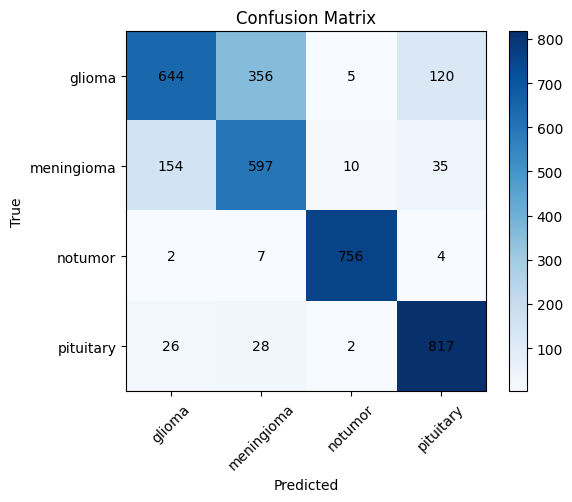

In [5]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        logits = model(images)
        preds = torch.argmax(logits, dim=1).cpu().numpy()

        all_preds.extend(preds.tolist())
        all_labels.extend(labels.numpy().tolist())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

macro_f1 = f1_score(all_labels, all_preds, average="macro")
print(f"Validation Macro F1: {macro_f1:.4f}")
print(classification_report(all_labels, all_preds, target_names=full_train_dataset.classes, digits=4))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(ticks=np.arange(num_classes), labels=full_train_dataset.classes, rotation=45)
plt.yticks(ticks=np.arange(num_classes), labels=full_train_dataset.classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

In [ ]:
# def predict_image(image_path, model, transform, class_names, device):
#     image = Image.open(image_path).convert("RGB")
#     x = transform(image).unsqueeze(0).to(device)

#     model.eval()
#     with torch.no_grad():
#         logits = model(x)
#         probs = torch.softmax(logits, dim=1).cpu().numpy().squeeze()

#     pred_idx = int(np.argmax(probs))
#     pred_class = class_names[pred_idx]
#     confidence = float(probs[pred_idx])
#     return pred_class, confidence, probs

# path = "./Dataset_preprocessed/scale_224/glioma/1.png"
# pred_class, confidence, probs = predict_image(sample_path, model, val_transform, full_train_dataset.classes, device)
# print(f"Prediction: {pred_class} | Confidence: {confidence:.4f}")